# Week 6

### Ex 6.1

In [38]:
import numpy as np

def gaussian1DKernel(sigma, kernel_size_factor=6):
    if sigma == 0:
        return np.array([[1]]), np.array([[0]])
    
    radius = int(np.ceil(kernel_size_factor * sigma))
    x = np.arange(-radius, radius + 1)  # this is your missing x
    
    g = np.exp(-0.5 * (x / sigma)**2)
    g = g / np.sum(g)  # normalize so it sums to 1
    
    gd = -(x / sigma**2) * g  # derivative of the (normalized) gaussian
    
    return g.reshape(-1, 1), gd.reshape(-1, 1)

### Ex 6.2

In [39]:
import cv2

def gaussianSmoothing(im, sigma):
    if im.ndim == 3:
        im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    im = im.astype(np.float64)

    if sigma == 0:
        # no smoothing possible; derivative via simple finite differences would be an option,
        # but simplest is to just return im unsmoothed and zero/undefined derivatives
        return im, np.zeros_like(im), np.zeros_like(im)

    g, gd = gaussian1DKernel(sigma)

    I = cv2.filter2D(im, -1, g)
    I = cv2.filter2D(I, -1, g.T)

    Ix = cv2.filter2D(im, -1, gd)
    Ix = cv2.filter2D(Ix, -1, g.T)

    Iy = cv2.filter2D(im, -1, g)
    Iy = cv2.filter2D(Iy, -1, gd.T)
    
    return I, Ix, Iy

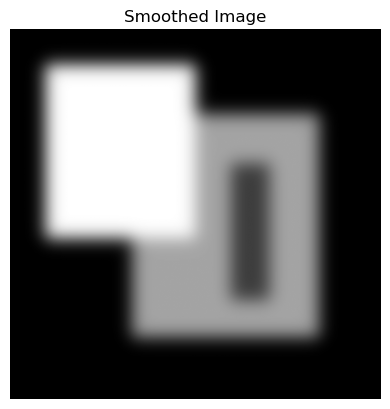

In [40]:
import matplotlib.pyplot as plt

im = cv2.imread('Figure1.png')
I, Ix, Iy = gaussianSmoothing(im, sigma=10.0)

plt.imshow(I, cmap='gray')   # I is already grayscale, no cvtColor needed
plt.title('Smoothed Image')
plt.axis('off')
plt.show()

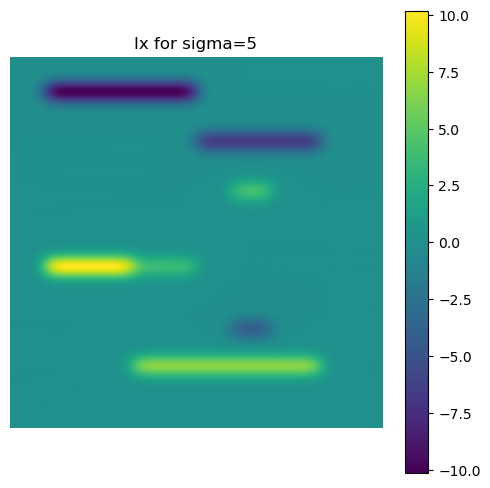

In [41]:
# --- Plot Ix with a diverging colormap ---
plt.figure(figsize=(6, 6))
vmax = np.abs(Ix).max()
plt.imshow(Ix, cmap='viridis', vmin=-vmax, vmax=vmax)
plt.colorbar()
plt.title('Ix for sigma=5')
plt.axis('off')
plt.show()

### Ex 6.3

In [42]:
def structureTensor(im, sigma, epsilon):
    I, Ix, Iy = gaussianSmoothing(im, sigma)
    
    g_eps, _ = gaussian1DKernel(epsilon)  # only need the smoothing kernel, not its derivative
    
    def smooth_eps(img):
        out = cv2.filter2D(img, -1, g_eps)
        out = cv2.filter2D(out, -1, g_eps.T)
        return out
    
    C11 = smooth_eps(Ix**2)
    C12 = smooth_eps(Ix * Iy)
    C22 = smooth_eps(Iy**2)
    
    # C is a 2x2 matrix at every pixel; store as a (H, W, 2, 2) array
    C = np.zeros((im.shape[0], im.shape[1], 2, 2))
    C[..., 0, 0] = C11
    C[..., 0, 1] = C12
    C[..., 1, 0] = C12
    C[..., 1, 1] = C22
    
    return C

### Ex 6.4

In [43]:
def harrisMeasure(im, sigma, epsilon, k):
    C = structureTensor(im, sigma, epsilon)
    a = C[..., 0, 0]
    b = C[..., 1, 1]
    c = C[..., 0, 1]
    r = (a * b - c**2) - k * (a + b)**2
    return r

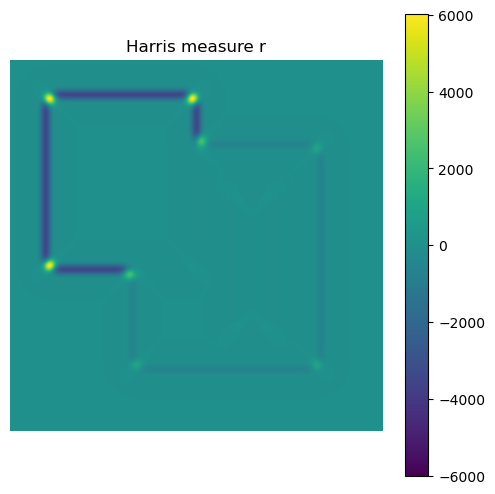

In [44]:
# --- Run it on your test image ---
im = cv2.imread('Figure1.png')

r = harrisMeasure(im, sigma=5, epsilon=5, k=0.06)

# --- Plot, matching Figure 3's style ---
plt.figure(figsize=(6, 6))
vmax = np.abs(r).max()
plt.imshow(r, cmap='viridis', vmin=-vmax, vmax=vmax)
plt.colorbar()
plt.title('Harris measure r')
plt.axis('off')
plt.show()

### Ex 6.5

In [45]:
def cornerDetector(im, sigma, epsilon, k, tau):
    r = harrisMeasure(im, sigma, epsilon, k)
    
    # --- Non-maximum suppression: check against the 4-neighborhood ---
    # Pad r so we can safely compare border pixels without index errors
    r_pad = np.pad(r, 1, mode='constant', constant_values=-np.inf)
    
    up    = r_pad[0:-2, 1:-1]
    down  = r_pad[2:  , 1:-1]
    left  = r_pad[1:-1, 0:-2]
    right = r_pad[1:-1, 2:  ]
    
    is_local_max = (r > up) & (r > down) & (r > left) & (r > right)
    
    # --- Threshold: relative to the max response ---
    above_thresh = r > (tau * r.max())
    
    corner_mask = is_local_max & above_thresh
    
    y_coords, x_coords = np.where(corner_mask)
    c = np.stack([x_coords, y_coords], axis=1)  # (N, 2) array of (x, y) points
    
    return c

Found 13 corners


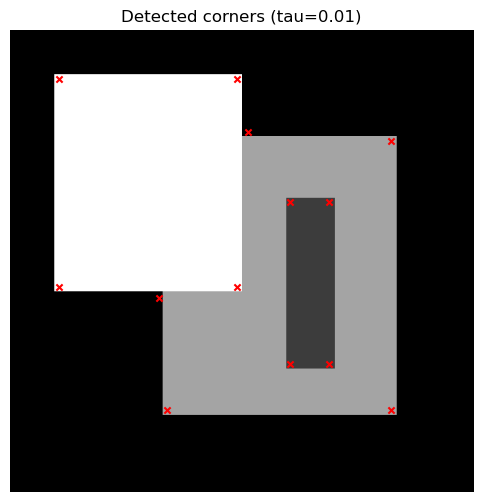

In [48]:
im = cv2.imread('Figure1.png')

sigma, epsilon, k, tau = 5, 5, 0.06, 0.01

corners = cornerDetector(im, sigma, epsilon, k, tau)
print(f"Found {len(corners)} corners")

plt.figure(figsize=(6, 6))
plt.imshow(im, cmap='gray')
plt.scatter(corners[:, 0], corners[:, 1], c='red', s=20, marker='x')
plt.title(f'Detected corners (tau={tau})')
plt.axis('off')
plt.show()

### Ex 6.6

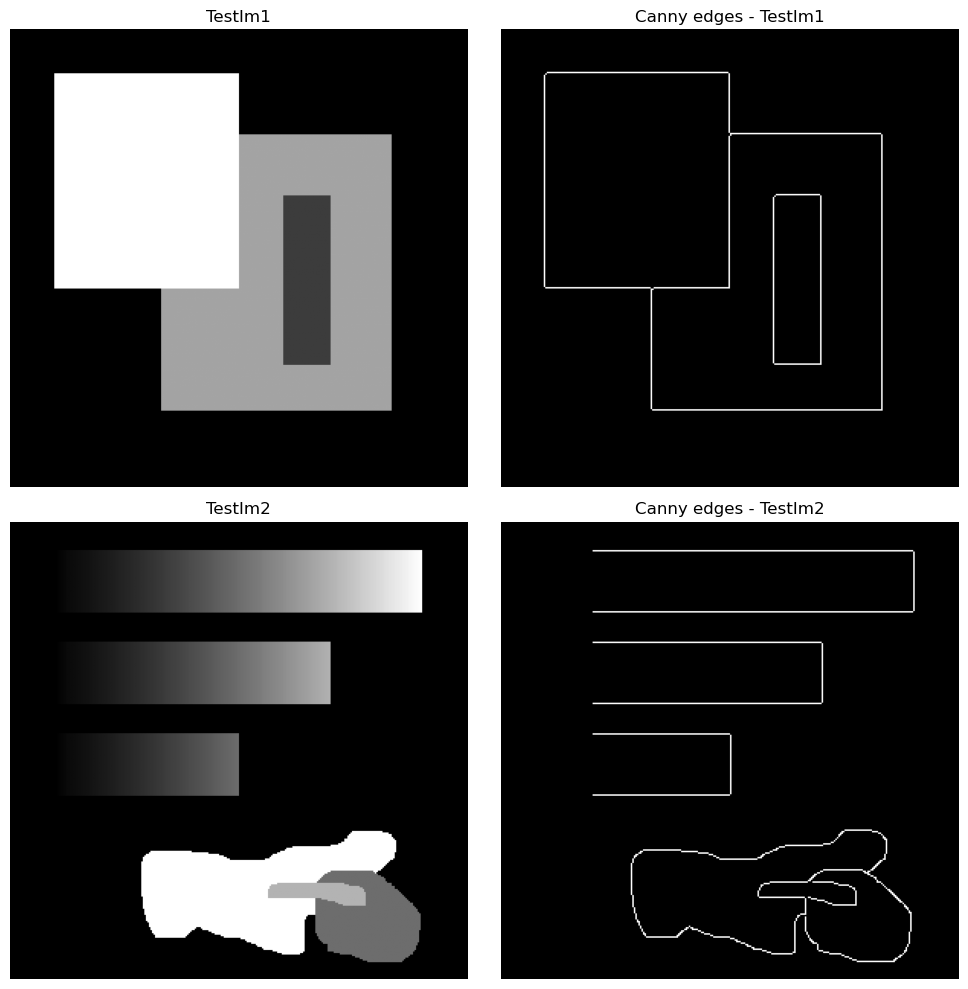

In [ ]:
im1 = cv2.imread('week06_data/TestIm1.png')
im2 = cv2.imread('week06_data/TestIm2.png')

im1 = cv2.imread('week06_data/TestIm1.png')
im2 = cv2.imread('week06_data/TestIm2.png')

im1_gray = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
im2_gray = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

edges1 = cv2.Canny(im1_gray, threshold1=100, threshold2=200)
edges2 = cv2.Canny(im2_gray, threshold1=100, threshold2=200)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs[0,0].imshow(im1_gray, cmap='gray')
axs[0,0].set_title('TestIm1')
axs[0,0].axis('off')

axs[0,1].imshow(edges1, cmap='gray')
axs[0,1].set_title('Canny edges - TestIm1')
axs[0,1].axis('off')

axs[1,0].imshow(im2_gray, cmap='gray')
axs[1,0].set_title('TestIm2')
axs[1,0].axis('off')

axs[1,1].imshow(edges2, cmap='gray')
axs[1,1].set_title('Canny edges - TestIm2')
axs[1,1].axis('off')

plt.tight_layout()
plt.show()

### Ex 6.7

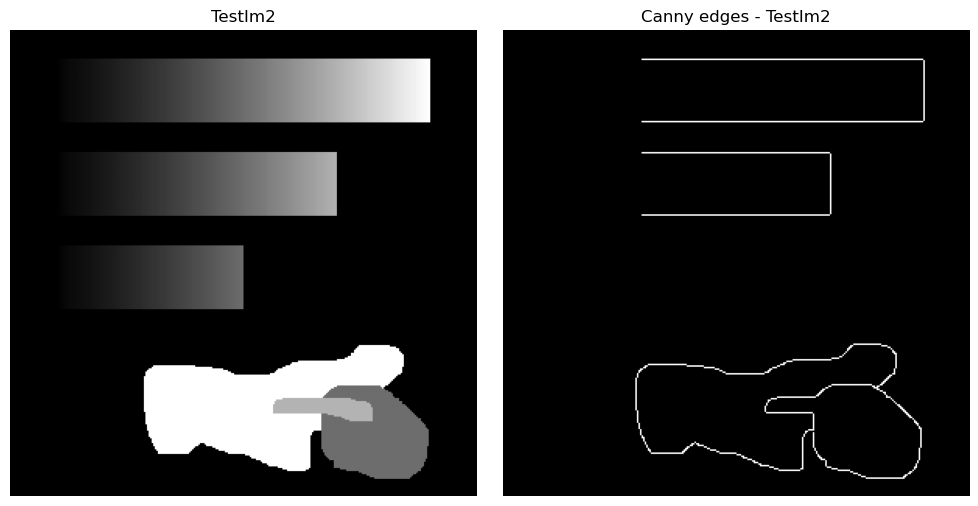

In [ ]:
im2 = cv2.imread('week06_data/TestIm2.png')

im2_gray = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

edges2 = cv2.Canny(im2_gray, threshold1=200, threshold2=200)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(im2_gray, cmap='gray')
axs[0].set_title('TestIm2')
axs[0].axis('off')

axs[1].imshow(edges2, cmap='gray')
axs[1].set_title('Canny edges - TestIm2')
axs[1].axis('off')

plt.tight_layout()
plt.show()